In [27]:
import subprocess

result = subprocess.run(["rsync -avz milkv@192.168.50.195:~/sophgo/smokewagon-benchmarks/apache/results /home/deppe/sophgo/smokewagon-benchmarks/apache"], capture_output=True, text=True, shell=True, check=True)
print(result.stdout)
print(result.stderr)

receiving incremental file list

sent 25 bytes  received 4,963 bytes  9,976.00 bytes/sec
total size is 171,629  speedup is 34.41




In [33]:
for name in ['smokewagon', 'baseline', 'inactive']:
    for i in range(1, 2):
        print(f"./apache/results/hey-output-{name}-{i:02d}.txt")

./apache/results/hey-output-smokewagon-01.txt
./apache/results/hey-output-baseline-01.txt
./apache/results/hey-output-inactive-01.txt


In [39]:
from pathlib import Path
import pandas as pd

dfs = []

for name in ['smokewagon', 'baseline', 'inactive']:
    rows = []
    for i in range(1, 56):
        file = Path(f"./apache/results/hey-output-{name}-{i:02d}.txt").read_text()
        for line in file.splitlines():
            if line.startswith("  Requests/sec:"):
                #print(float(line.split(":")[1].strip()))
                rows.append({"cores" : i, name : float(line.split(":")[1].strip())})
    
    dfs.append(pd.DataFrame(rows).set_index('cores'))

df = pd.concat(dfs, axis='columns')
del dfs
df

,smokewagon,baseline,inactive
cores,,,
1,1177.7113,1179.5614,1154.0889
2,1996.9458,1922.6345,1967.1616
3,2603.9029,2494.3084,2479.6023
4,3272.9181,3215.6306,3166.6870
5,3557.1208,3571.7450,3478.3354
6,3637.2693,3602.8123,3613.0845
7,3643.4628,3669.2172,3622.3903
8,3660.1786,3717.0135,3662.3251
9,3582.4434,3716.3679,3624.5676


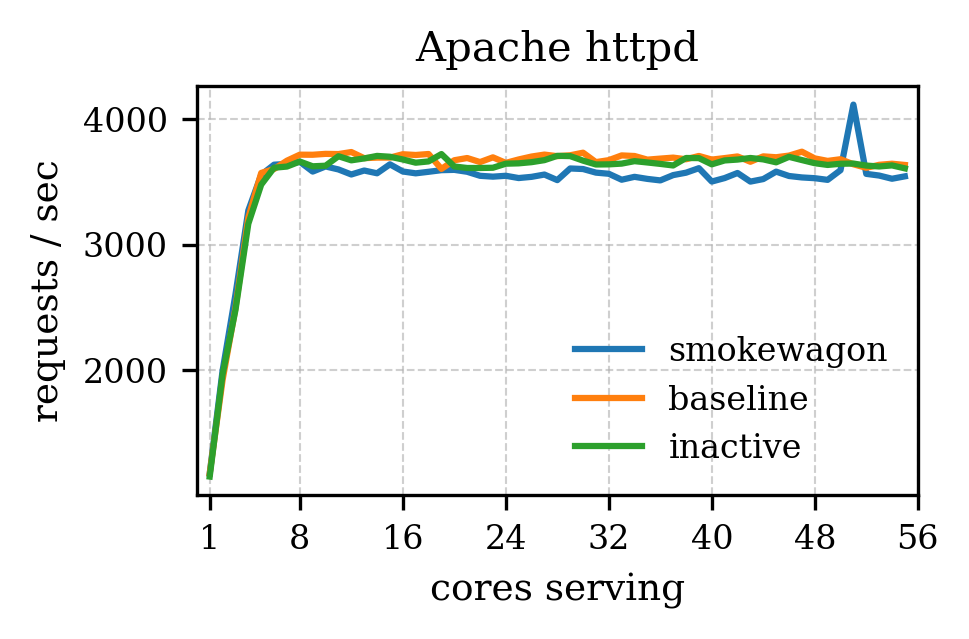

In [42]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(3.3, 2.2))  # ACM single-column width
ax.plot(df.index, df.values)
ax.set_title("Apache httpd")
ax.set_xlabel("cores serving")
ax.set_ylabel("requests / sec")
ax.set_xlim(left=0, right=21)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(df.columns, frameon=False)
plt.tight_layout()
plt.savefig("apache-benchmark.pdf", bbox_inches="tight")